In [323]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [357]:
# reading the csv of variable dictionaries
dictionary = pd.read_csv(r"C:\Users\user\Desktop\Project\a Health data\Variable_explanations.csv")
dictionary

,name,detail
0,surveyid,Individual Identifier
1,village,Village Identifier
2,survey_date,Date of Interview (days since Jan1 of first year)
3,femaleres,Female respondent
4,age,Age (respondent)
...,...,...
70,saved_mpesa,Saved money using M-Pesa
71,amount_saved_mpesa,Amount saved using M-Pesa
72,early_survey,Psychology survey in 1st wave (dummy)
73,depressed,Meets epidemiological threshold for moderate d...


In [439]:
# reading the train  csv file
train = pd.read_csv(r"C:\Users\user\Desktop\Project\a Health data\train.csv")
# reading the test file
test =  pd.read_csv(r"C:\Users\user\Desktop\Project\a Health data\test.csv")

In [411]:
#creating backup
train_copy = train.copy()

In [412]:
train.head()

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,23-Nov-61,1,28.0,1,4,6,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,24-Oct-61,1,23.0,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,05-Oct-61,1,22.0,1,3,5,9,0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,23-Sep-61,1,27.0,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,12-Sep-61,0,59.0,0,4,6,10,4,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3


In [413]:
train.shape

(1143, 75)

In [414]:
# checking  train info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 1143 non-null   int64  
 1   village                  1143 non-null   int64  
 2   survey_date              1143 non-null   object 
 3   femaleres                1143 non-null   int64  
 4   age                      1143 non-null   float64
 5   married                  1143 non-null   int64  
 6   children                 1143 non-null   int64  
 7   hhsize                   1143 non-null   int64  
 8   edu                      1143 non-null   int64  
 9   hh_children              1143 non-null   int64  
 10  hh_totalmembers          809 non-null    float64
 11  cons_nondurable          1143 non-null   float64
 12  asset_livestock          1143 non-null   float64
 13  asset_durable            1143 non-null   float64
 14  asset_phone             

In [440]:
# calculating the missing  values 
print(f"the columns of Train with null values and their percentage")
percentage =(train.isnull().mean()*100).round(2)
for col in train.columns:
    if percentage[col] >0:
        print(f"{col} :{percentage[col]}%")


the columns of Train with null values and their percentage
hh_totalmembers :29.22%
cons_alcohol :3.76%
cons_tobacco :1.75%
cons_med_children :36.66%
fs_chskipm_often :36.4%
fs_chwholed_often :36.4%
fs_meat :29.22%
fs_enoughtom :29.22%
fs_sleephun :29.22%
med_expenses_hh_ep :60.63%
med_expenses_sp_ep :76.82%
med_expenses_child_ep :52.49%
med_portion_sickinjured :29.22%
med_port_sick_child :36.4%
med_afford_port :37.01%
med_sickdays_hhave :29.22%
med_healthconsult :37.01%
med_u5_deaths :94.84%
ed_expenses :40.51%
ed_expenses_perkid :40.51%
ed_schoolattend :40.51%
ed_sch_missedpc :40.86%
ed_work_act_pc :49.96%


In [441]:
# calculating the missing  values 
print(f"the columns of Test with null values and their percentage")
percentage =(test.isnull().mean()*100).round(2)
for col in test.columns:
    if percentage[col] >0:
        print(f"{col} :{percentage[col]}%")


the columns of Test with null values and their percentage
age :0.35%
hh_totalmembers :31.47%
cons_alcohol :4.2%
cons_tobacco :2.45%
cons_med_children :38.46%
fs_chskipm_often :38.11%
fs_chwholed_often :38.11%
fs_meat :31.47%
fs_enoughtom :31.47%
fs_sleephun :31.47%
med_expenses_hh_ep :61.54%
med_expenses_sp_ep :79.72%
med_expenses_child_ep :52.1%
med_portion_sickinjured :31.47%
med_port_sick_child :38.11%
med_afford_port :38.81%
med_sickdays_hhave :31.47%
med_healthconsult :38.81%
med_u5_deaths :95.8%
ed_expenses :40.21%
ed_expenses_perkid :40.21%
ed_schoolattend :40.21%
ed_sch_missedpc :40.56%
ed_work_act_pc :51.05%
depressed :98.6%


## Imputing missing values

### handle with missing values


High Missing (50–80%) → Replace With 0

These usually mean no expense / no event occurred:

med_expenses_sp_ep
med_expenses_hh_ep
med_expenses_child_ep

assumption : If someone did not go to hospital → expense = 0 → not missing actually.

Medium Missing (30–50%) → Fill With Median
Columns of:

ed_expenses

ed_expenses_perkid

ed_schoolattend

fs_chskipm_often

fs_chwholed_often

med_port_sick_child

med_afford_port


Lower Missing (10–30%) → Median

Columns:

hh_totalmembers

fs_meat

fs_enoughtom

fs_sleephun

med_portion_sickinjured

med_sickdays_hhave


In [442]:
def handle_missing(train):

    # 1. Drop very high missing

    drop_cols = ['med_u5_deaths']
    train = train.drop(columns=drop_cols, errors='ignore')
  
    #  Fill high missing with 0
   
    cols_zero = [
        'med_expenses_sp_ep',
        'med_expenses_hh_ep',
        'med_expenses_child_ep'
    ]

    for col in cols_zero:
        value = 0
        train[col] = train[col].fillna(value)

    
    # Fill medium missing with median
    
    cols_median = [
        'ed_expenses',
        'ed_expenses_perkid',
        'ed_schoolattend',
        'fs_chskipm_often',
        'fs_chwholed_often',
        'med_port_sick_child',
        'med_afford_port',
        'hh_totalmembers',
        'fs_meat',
        'fs_enoughtom',
        'fs_sleephun',
        'med_portion_sickinjured',
        'med_sickdays_hhave',
        'med_healthconsult',
        'ed_sch_missedpc',
        'ed_work_act_pc'
    ]

    for col in cols_median:
        median_value = train[col].median()
        train[col] = train[col].fillna(median_value)
       
    # Fill low missing with mode
    cols_mode = [
        'cons_alcohol',
        'cons_tobacco'
    ]

    for col in cols_mode:
        mode_value = train[col].mode()[0]
        train[col] = train[col].fillna(mode_value)


    return train

In [443]:
train = handle_missing(train)

In [444]:
train.isnull().sum()

surveyid              0
village               0
survey_date           0
femaleres             0
age                   0
                     ..
saved_mpesa           0
amount_saved_mpesa    0
early_survey          0
depressed             0
day_of_week           0
Length: 74, dtype: int64

In [445]:
def handle_missing_test(test, train):
    """
    Fill missing values in test data using statistics from train.
    Target column is ignored.
    """

    # Drop columns with >90% missing in train
    drop_cols = ['med_u5_deaths']
    test = test.drop(columns=[c for c in drop_cols if c in test.columns], errors='ignore')

    # Fill high missing (50-80%) with 0
    cols_zero = [
        'med_expenses_sp_ep',
        'med_expenses_hh_ep',
        'med_expenses_child_ep'
    ]
    for col in cols_zero:
        if col in test.columns:
            test[col] = test[col].fillna(0)

    # Fill medium missing (20-50%) with train median
    cols_median = [
        'ed_expenses',
        'ed_expenses_perkid',
        'ed_schoolattend',
        'ed_sch_missedpc',
        'ed_work_act_pc',
        'fs_chskipm_often',
        'fs_chwholed_often',
        'med_port_sick_child',
        'med_afford_port',
        'hh_totalmembers',
        'fs_meat',
        'fs_enoughtom',
        'fs_sleephun',
        'med_portion_sickinjured',
        'med_sickdays_hhave',
        'med_healthconsult',
        'cons_med_children'
    ]
    for col in cols_median:
        if col in test.columns:
            test[col] = test[col].fillna(train[col].median())

    # Fill low missing (<10%) with train mode
    cols_mode = ['cons_alcohol','cons_tobacco','age']
    for col in cols_mode:
        if col in test.columns:
            test[col] = test[col].fillna(train[col].mode()[0])

    return test

In [446]:
test = handle_missing_test(test, train)

In [447]:
test.isnull().sum()

surveyid                0
village                 0
survey_date             0
femaleres               0
age                     0
                     ... 
saved_mpesa             0
amount_saved_mpesa      0
early_survey            0
depressed             282
day_of_week             0
Length: 74, dtype: int64

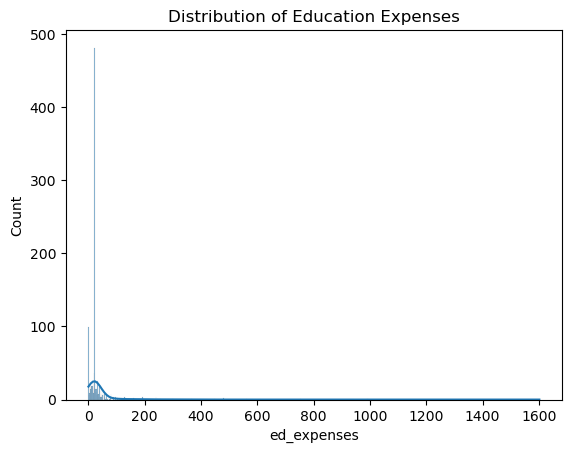

In [338]:
sns.histplot(train['ed_expenses'], kde=True)
plt.title("Distribution of Education Expenses")
plt.show()

In [423]:
print(train['depressed'].value_counts())
print(train['depressed'].isnull().sum())

depressed
0    950
1    193
Name: count, dtype: int64
0


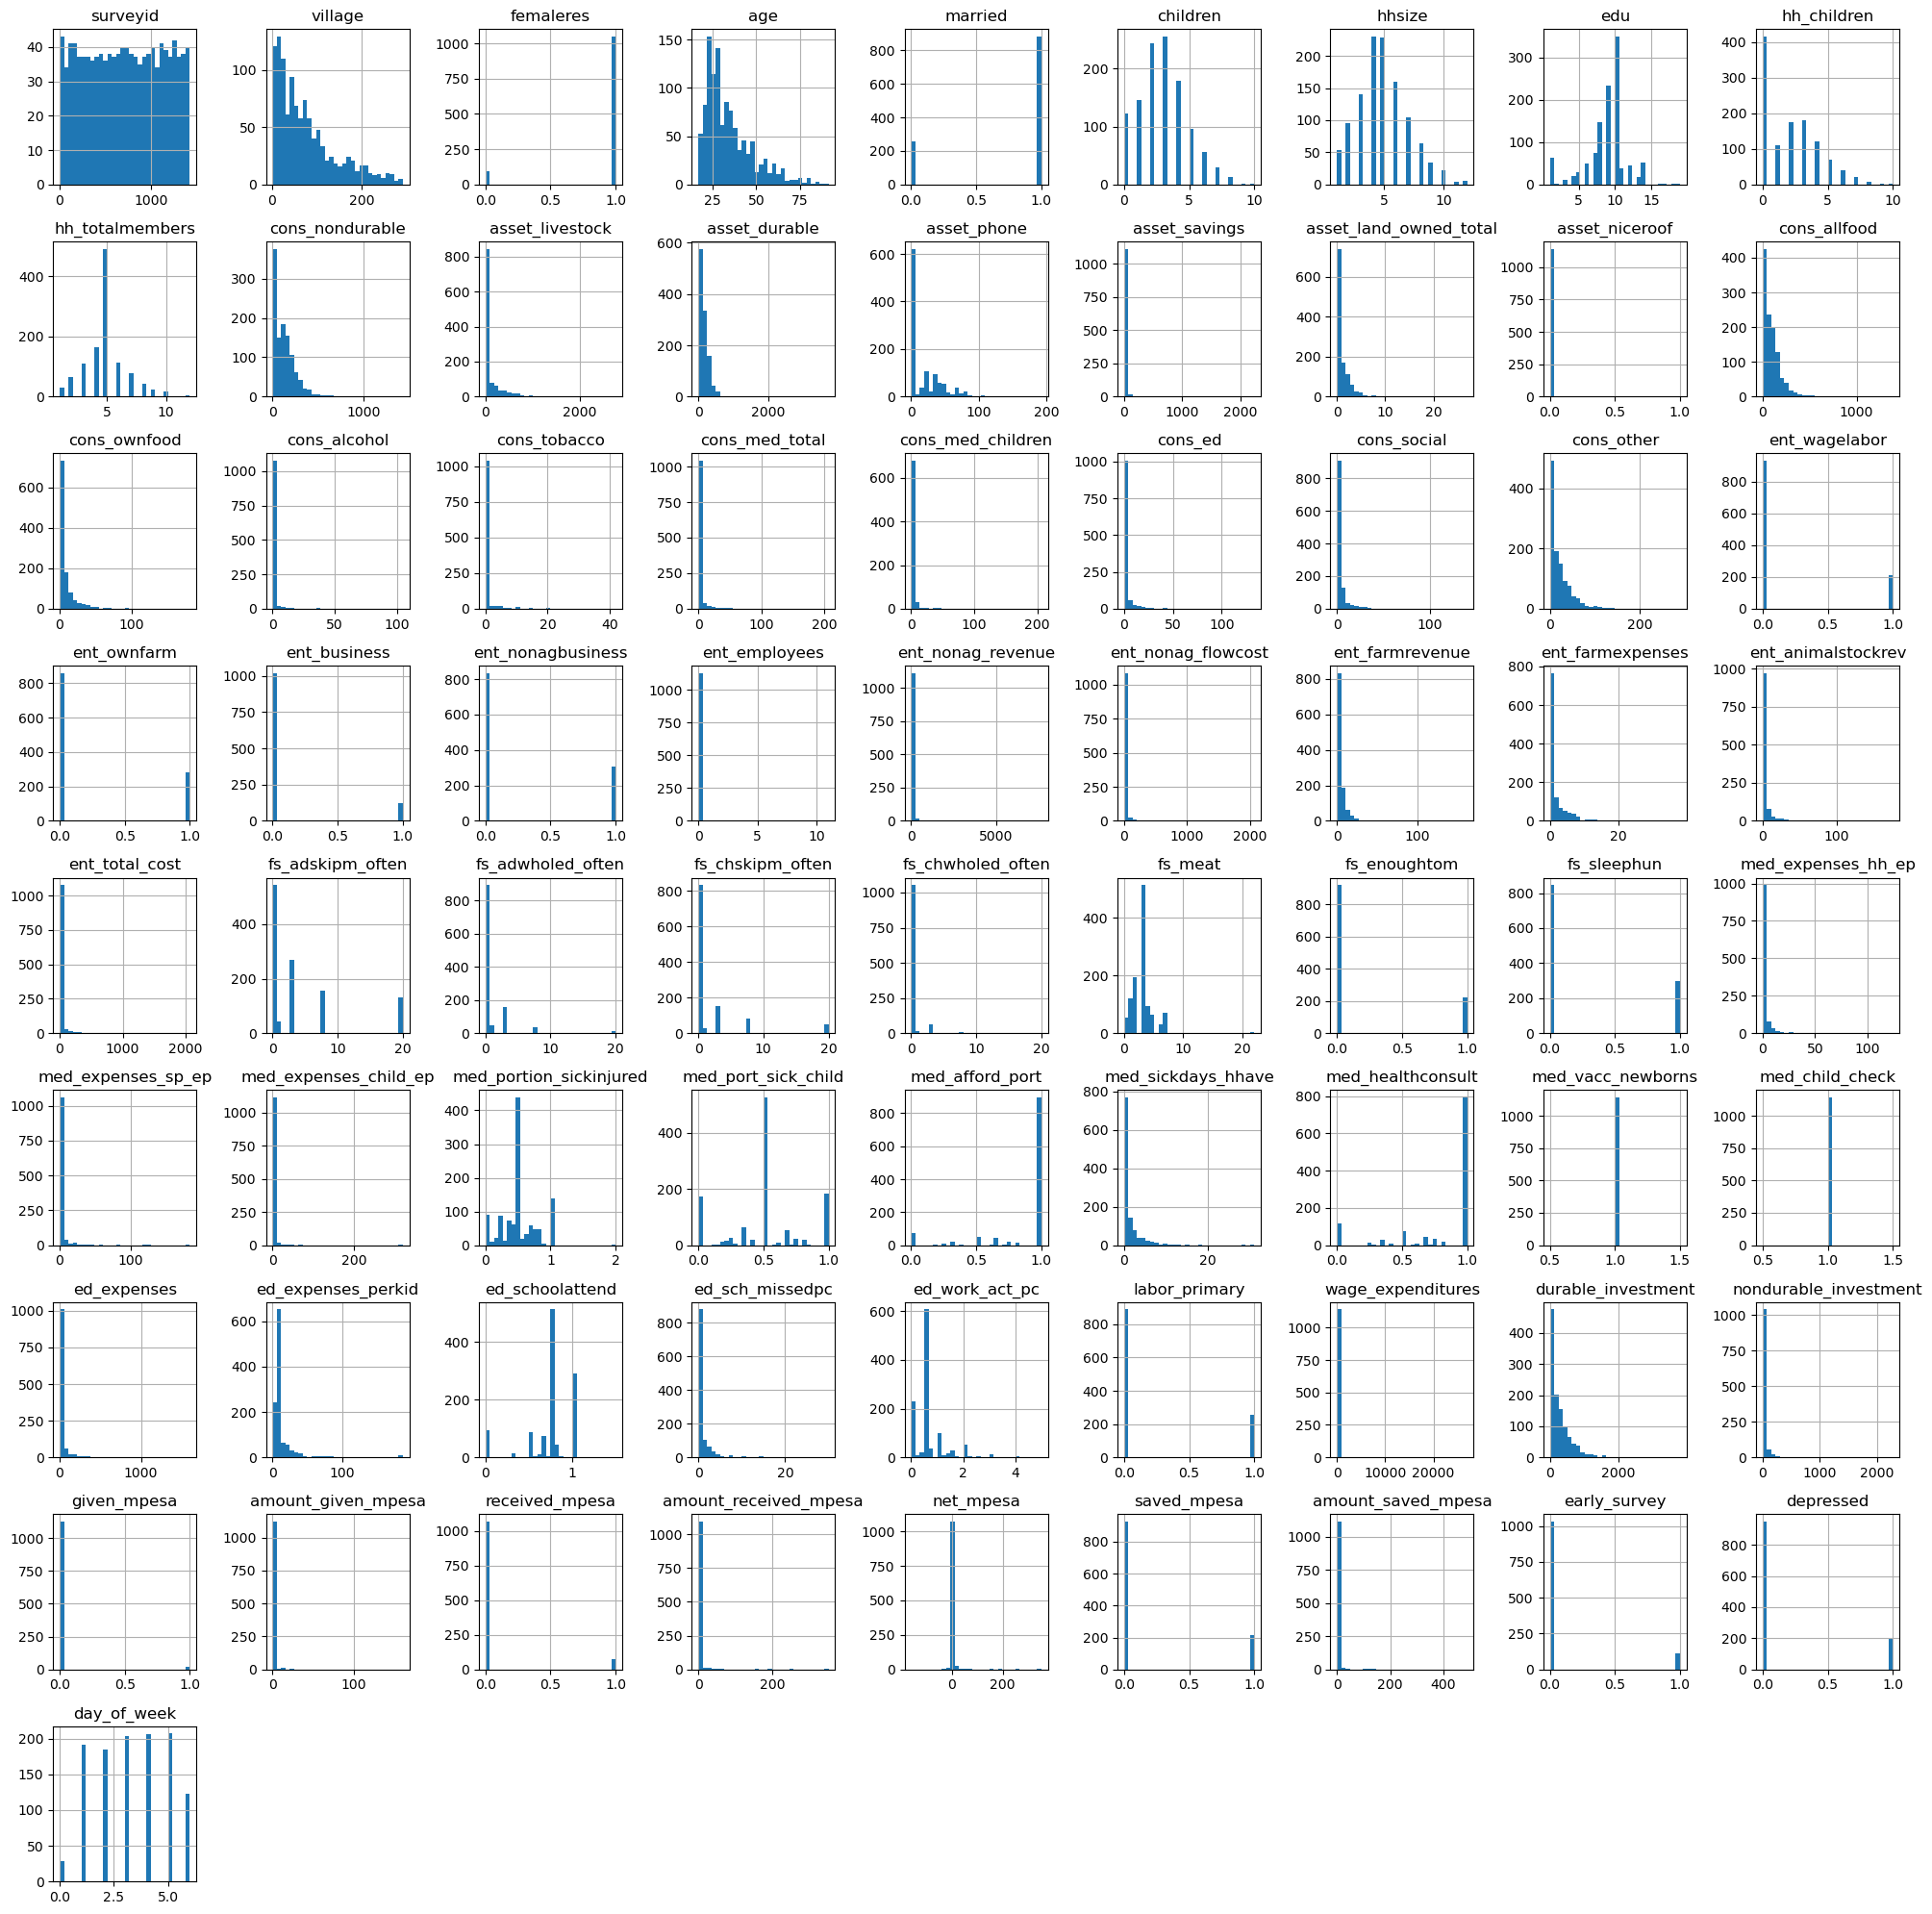

In [340]:
train.hist(figsize=(20,20), bins=30)
plt.tight_layout()
plt.show()

# correclation analysis

Check class balance of depressed

Correlation analysis

Feature selection

Train Logistic Regression

In [354]:
corr = train.corr(numeric_only=True)

corr_depressed = corr['depressed'].sort_values(ascending=False)
print(corr_depressed)

corr

depressed             1.000000
fs_adwholed_often     0.143458
med_expenses_sp_ep    0.135494
age                   0.100159
fs_chwholed_often     0.099581
                        ...   
married              -0.078541
edu                  -0.122236
med_u5_deaths        -0.158007
med_vacc_newborns          NaN
med_child_check            NaN
Name: depressed, Length: 74, dtype: float64


,surveyid,village,femaleres,age,married,children,hhsize,edu,hh_children,hh_totalmembers,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
surveyid,1.000000,0.662797,0.025247,0.041632,-0.015671,0.031325,0.027476,-0.039734,-0.000358,0.024113,...,0.045888,0.040764,-0.021107,0.000453,-0.009799,0.072213,0.020514,-0.073316,-0.019913,0.007106
village,0.662797,1.000000,-0.008408,0.001868,0.022867,0.039394,0.034232,-0.009572,-0.041124,0.027366,...,0.027330,0.006922,-0.039510,0.008756,0.006716,0.063153,0.001042,-0.069818,0.015881,-0.028304
femaleres,0.025247,-0.008408,1.000000,-0.137133,0.275119,0.224375,0.256443,-0.075308,0.197696,0.257334,...,0.012628,0.018648,-0.034134,-0.034100,-0.037609,0.007713,-0.008594,0.003292,-0.008112,0.003938
age,0.041632,0.001868,-0.137133,1.000000,-0.400452,-0.111424,-0.068531,-0.393277,-0.070510,-0.047794,...,-0.026741,-0.025685,0.046239,0.016848,0.022718,-0.095900,-0.018136,-0.063066,0.100159,0.028122
married,-0.015671,0.022867,0.275119,-0.400452,1.000000,0.220000,0.322867,0.197570,0.152999,0.295652,...,0.051875,0.041664,-0.022720,0.007061,-0.003645,0.070017,0.034929,0.003347,-0.078541,-0.057146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
saved_mpesa,0.072213,0.063153,0.007713,-0.095900,0.070017,0.035391,0.035991,0.080371,0.017773,0.015912,...,0.028692,0.016197,0.077481,0.064039,0.057767,1.000000,0.222436,-0.053862,-0.014749,-0.026371
amount_saved_mpesa,0.020514,0.001042,-0.008594,-0.018136,0.034929,-0.004842,-0.016109,0.039023,0.014934,0.012571,...,0.053702,0.010897,0.042999,0.029160,0.025419,0.222436,1.000000,-0.015620,-0.024712,0.051611
early_survey,-0.073316,-0.069818,0.003292,-0.063066,0.003347,-0.024424,-0.029693,0.042708,0.115244,-0.043465,...,-0.041691,-0.020857,-0.040716,0.019411,0.023981,-0.053862,-0.015620,1.000000,0.000694,0.034737
depressed,-0.019913,0.015881,-0.008112,0.100159,-0.078541,0.012671,0.005681,-0.122236,0.007477,0.069460,...,-0.019497,0.000751,-0.007807,0.005464,0.005087,-0.014749,-0.024712,0.000694,1.000000,-0.019514


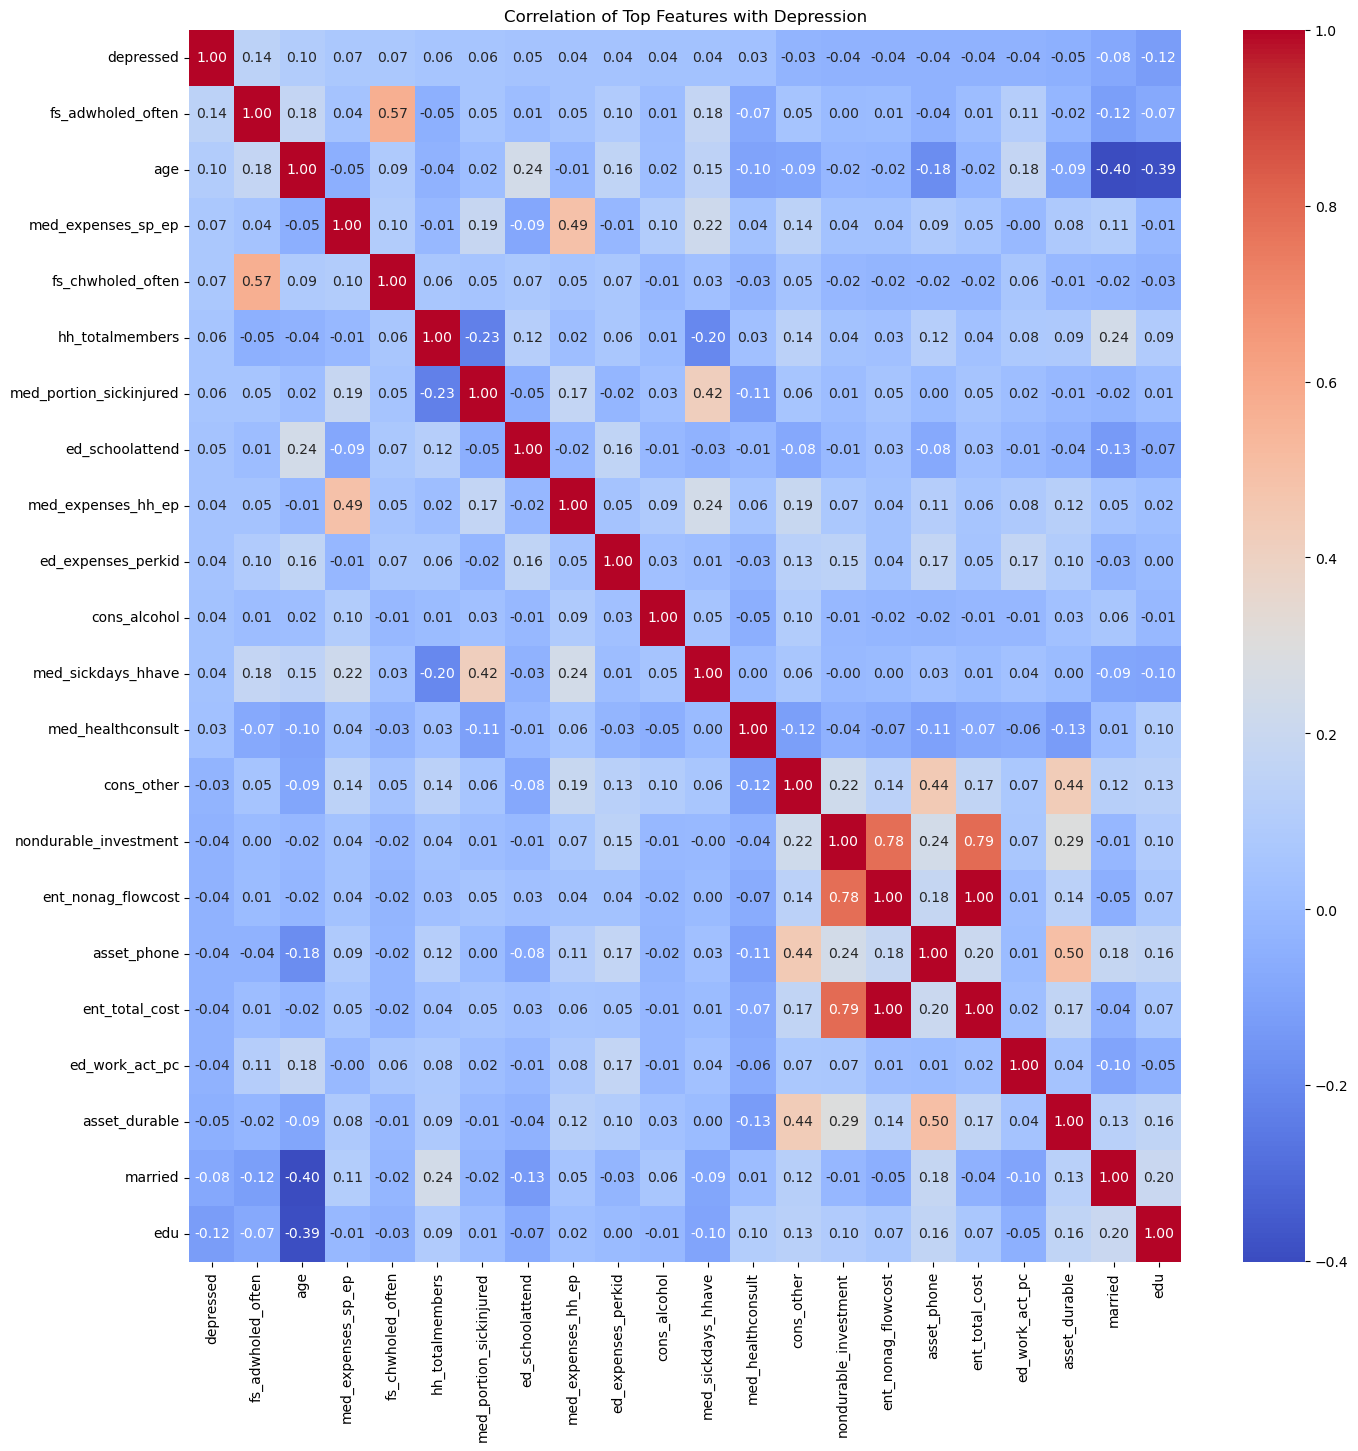

In [342]:
# Compute correlations
corr = train.corr(numeric_only=True)

# Take only features with abs(correlation) > threshold (e.g., 0.05) with depressed
threshold = 0.03
top_features = corr['depressed'][abs(corr['depressed']) > threshold].sort_values(ascending=False).index

# Plot heatmap of these features
plt.figure(figsize=(16,16))
sns.heatmap(train[top_features].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation of Top Features with Depression")
plt.show()

#### Check for Multicollinearity

depressed             1.000000
fs_adwholed_often     0.143458
med_expenses_sp_ep    0.135494
age                   0.100159
fs_chwholed_often     0.099581
                        ...   
married              -0.078541
edu                  -0.122236
med_u5_deaths        -0.158007
med_vacc_newborns          NaN
med_child_check            NaN
Name: depressed, Length: 74, dtype: float64
Selected features: ['fs_adwholed_often', 'med_expenses_sp_ep', 'age', 'fs_chwholed_often', 'med_portion_sickinjured', 'hh_totalmembers', 'ed_expenses_perkid', 'ed_schoolattend', 'med_sickdays_hhave', 'fs_chskipm_often', 'med_healthconsult', 'cons_alcohol', 'fs_sleephun', 'med_expenses_hh_ep', 'cons_other', 'nondurable_investment', 'ent_nonag_flowcost', 'asset_phone', 'ent_total_cost', 'asset_durable', 'ed_work_act_pc', 'married', 'edu', 'med_u5_deaths']


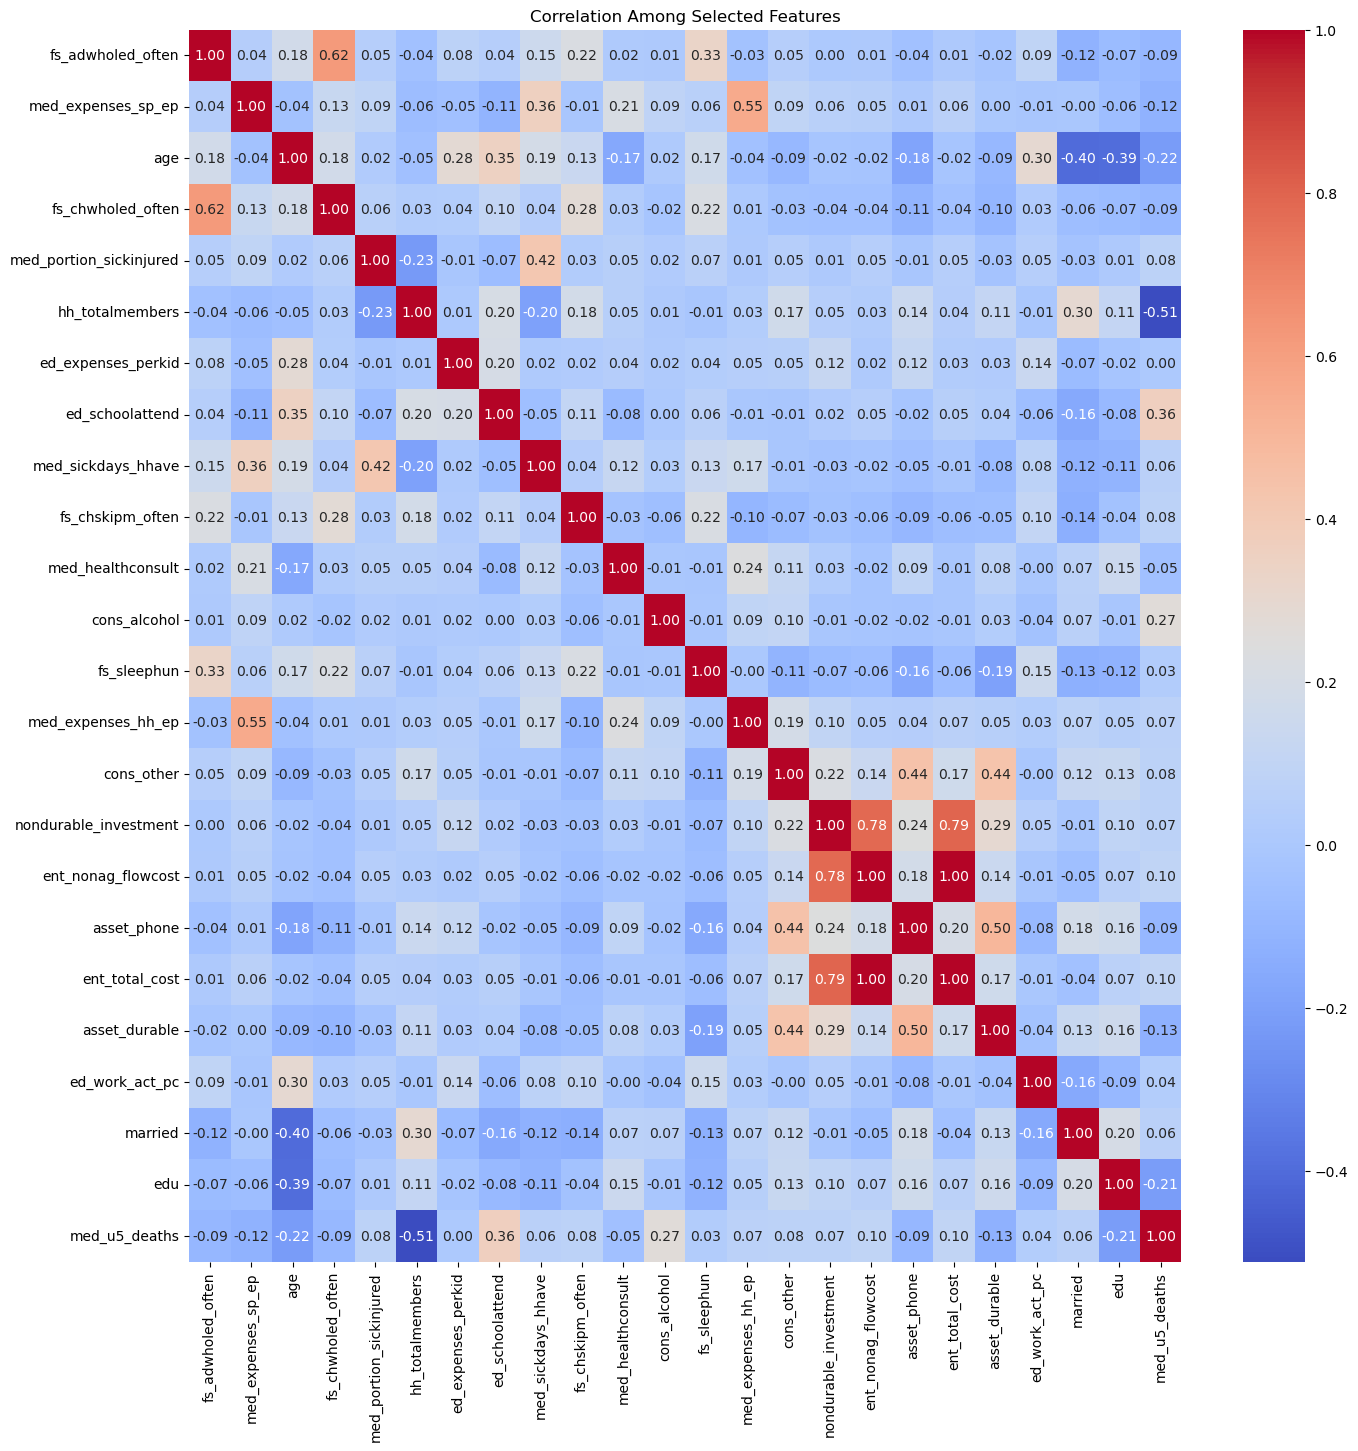

In [355]:


corr_target = train.corr(numeric_only=True)['depressed'].sort_values(ascending=False)
print(corr_target)

# Selected features with correlation above threshold
threshold = 0.03
selected_features = corr_target[abs(corr_target) > threshold].index.tolist()

# Remove the target itself
selected_features.remove('depressed')
print("Selected features:", selected_features)

plt.figure(figsize=(16,16))
sns.heatmap(train[selected_features].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Among Selected Features")
plt.show()

## full feature engineering

In [448]:

# Define target and ID
target = 'depressed'
id_col = 'surveyid'

# Step 1: Select numeric columns, exclude surveyid
num_cols = [col for col in train.select_dtypes(include=['int64', 'float64']).columns if col != id_col]

# Step 2: Remove highly correlated features (threshold >0.7)
corr_matrix = train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.7)]
print("Features to remove due to high correlation (>0.6):")
print(to_drop)

train = train.drop(columns=to_drop)
print("\nRemaining columns after removing highly correlated features:")
print(train_reduced.columns)

# Step 3: Correlation with target
corr_with_target = train.corr(numeric_only=True)[target].abs()

# Remove target from correlation list first (safe)
corr_with_target = corr_with_target.drop(target, errors='ignore')

# Select low correlation features
low_corr_features = [col for col in corr_with_target.index if corr_with_target[col] < 0.02 and col != id_col]

print("\nFeatures to remove due to LOW correlation with target:")
print(low_corr_features)

# Step 4: Drop low-correlation features
train = train.drop(columns=low_corr_features)

# Ensure surveyid is kept
if id_col not in train.columns:
    train[id_col] = train[id_col]

print("\nFinal remaining features (surveyid preserved):")
print(train.columns)

Features to remove due to high correlation (>0.6):
['hhsize', 'hh_totalmembers', 'cons_allfood', 'cons_ownfood', 'cons_med_children', 'ent_animalstockrev', 'ent_total_cost', 'med_port_sick_child', 'ed_expenses', 'ed_expenses_perkid', 'labor_primary', 'durable_investment', 'nondurable_investment', 'net_mpesa']

Remaining columns after removing highly correlated features:
Index(['surveyid', 'survey_date', 'age', 'married', 'edu', 'cons_nondurable',
       'asset_livestock', 'asset_durable', 'asset_phone', 'cons_alcohol',
       'cons_med_total', 'cons_other', 'ent_business', 'ent_employees',
       'ent_nonag_flowcost', 'ent_farmrevenue', 'fs_adwholed_often',
       'fs_chskipm_often', 'fs_chwholed_often', 'fs_enoughtom',
       'med_expenses_hh_ep', 'med_expenses_sp_ep', 'med_portion_sickinjured',
       'med_sickdays_hhave', 'med_healthconsult', 'med_vacc_newborns',
       'med_child_check', 'ed_schoolattend', 'ed_work_act_pc',
       'amount_saved_mpesa', 'depressed', 'total_assets', 

In [449]:
test = test[train.columns]

In [450]:
test.shape, train.shape

((286, 31), (1143, 31))

### checking class Imbalance

In [459]:
train['depressed'].value_counts()

depressed
0    950
1    193
Name: count, dtype: int64

In [460]:
from sklearn.utils import resample
import pandas as pd

# 1. Separate majority and minority classes
df_majority = train[train['depressed'] == 0]
df_minority = train[train['depressed'] == 1]

# 2. Oversample minority class to match majority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,     # Sample with replacement to "duplicate" rows
                                 n_samples=len(df_majority), # Match the number of majority samples
                                 random_state=42) 

# 3. Combine majority class with upsampled minority
train_reduced = pd.concat([df_majority, df_minority_upsampled])

# 4. Shuffle the dataset
train_reduced = train_reduced.sample(frac=1, random_state=42).reset_index(drop=True)


In [461]:
#train_reduced = train
train_reduced['depressed'].value_counts()

depressed
1    950
0    950
Name: count, dtype: int64

### Feature Engineering

In [451]:
train_reduced['total_assets'] = train_reduced['asset_livestock'] + train_reduced['asset_durable'] + train_reduced['asset_phone']
test['total_assets'] = test['asset_livestock'] + test['asset_durable'] + test['asset_phone']

# ------------------------
# 2. Total income
# ------------------------
train_reduced['total_income'] = train_reduced['ent_farmrevenue'] + train_reduced['ent_nonag_flowcost']
test['total_income'] = test['ent_farmrevenue'] + test['ent_nonag_flowcost']

# ------------------------
# 3. Total expenses
# ------------------------
train_reduced['total_expenses'] = train_reduced['cons_nondurable'] + train_reduced.get('cons_other', 0)
test['total_expenses'] = test['cons_nondurable'] + test.get('cons_other', 0)

# ------------------------
# 4. Expense to income ratio
# ------------------------
train_reduced['expense_to_income_ratio'] = train_reduced['total_expenses'] / (train_reduced['total_income'] + 1e-6)
test['expense_to_income_ratio'] = test['total_expenses'] / (test['total_income'] + 1e-6)

# ------------------------
# 5. Household children ratio
# ------------------------
if 'hh_children' in train_reduced.columns:
    train_reduced['children_ratio'] = train_reduced['hh_children'] / (train_reduced['total_assets'] + 1e-6)
    test['children_ratio'] = test['hh_children'] / (test['total_assets'] + 1e-6)

# ------------------------
# 6. Health and education per child
# ------------------------
train_reduced['med_per_child'] = train_reduced['med_expenses_hh_ep'] / train_reduced.get('hh_children', 1)
test['med_per_child'] = test['med_expenses_hh_ep'] / test.get('hh_children', 1)

train_reduced['edu_per_child'] = train_reduced['ed_schoolattend'] / train_reduced.get('hh_children', 1)
test['edu_per_child'] = test['ed_schoolattend'] / test.get('hh_children', 1)

# ------------------------
# 7. Binary flags for assets
# ------------------------
train_reduced['has_phone'] = (train_reduced['asset_phone'] > 0).astype(int)
test['has_phone'] = (test['asset_phone'] > 0).astype(int)

train_reduced['has_livestock'] = (train_reduced['asset_livestock'] > 0).astype(int)
test['has_livestock'] = (test['asset_livestock'] > 0).astype(int)

train_reduced['has_durable_assets'] = (train_reduced['asset_durable'] > 0).astype(int)
test['has_durable_assets'] = (test['asset_durable'] > 0).astype(int)

In [431]:
test.shape, train_reduced.shape

((286, 40), (1900, 40))

In [452]:
test.dtypes

surveyid                     int64
survey_date                 object
age                         object
married                      int64
edu                          int64
cons_nondurable            float64
asset_livestock            float64
asset_durable              float64
asset_phone                float64
cons_alcohol               float64
cons_med_total             float64
cons_other                 float64
ent_business                 int64
ent_employees                int64
ent_nonag_flowcost         float64
ent_farmrevenue            float64
fs_adwholed_often          float64
fs_chskipm_often           float64
fs_chwholed_often          float64
fs_enoughtom               float64
med_expenses_hh_ep         float64
med_expenses_sp_ep         float64
med_portion_sickinjured    float64
med_sickdays_hhave         float64
med_healthconsult          float64
med_vacc_newborns            int64
med_child_check              int64
ed_schoolattend            float64
ed_work_act_pc      

## Model development

In [462]:

train_ids = train_reduced['surveyid']
test_ids = test['surveyid']

X_train = train_reduced.drop(columns=['surveyid','survey_date','depressed'])
y_train = train_reduced['depressed']  # target

X_test = test.drop(columns=['surveyid'])

X_test = X_test[X_train.columns] 

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1900, 28)
Test shape: (286, 28)


In [463]:
test['age'] = pd.to_numeric(test['age'], errors='coerce')
test.dtypes

surveyid                     int64
survey_date                 object
age                        float64
married                      int64
edu                          int64
cons_nondurable            float64
asset_livestock            float64
asset_durable              float64
asset_phone                float64
cons_alcohol               float64
cons_med_total             float64
cons_other                 float64
ent_business                 int64
ent_employees                int64
ent_nonag_flowcost         float64
ent_farmrevenue            float64
fs_adwholed_often          float64
fs_chskipm_often           float64
fs_chwholed_often          float64
fs_enoughtom               float64
med_expenses_hh_ep         float64
med_expenses_sp_ep         float64
med_portion_sickinjured    float64
med_sickdays_hhave         float64
med_healthconsult          float64
med_vacc_newborns            int64
med_child_check              int64
ed_schoolattend            float64
ed_work_act_pc      

In [406]:
# standardization

from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


print("Train sample after scaling:")
print(X_train.head())

print("\nTest sample after scaling:")
print(X_test.head())

print("\nShapes:")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train sample after scaling:
        age   married       edu  cons_nondurable  asset_livestock  \
0  0.276917  0.592749 -1.107280         1.731241         0.889463   
1 -0.877397 -1.687055 -0.134635        -0.170308        -0.349431   
2 -0.809496 -1.687055  0.513796         0.235770        -0.289731   
3  0.616422  0.592749  0.189581        -0.951462        -0.424055   
4 -0.266289 -1.687055  0.189581        -0.183383        -0.379280   

   asset_durable  asset_phone  cons_alcohol  cons_med_total  ent_business  \
0       0.662059     0.742500     -0.179247       -0.255477     -0.329421   
1       0.662059     1.933525     -0.179247       -0.255477     -0.329421   
2       0.427328    -0.675386     -0.179247       -0.255477     -0.329421   
3      -0.796116    -0.675386     -0.179247       -0.255477     -0.329421   
4      -0.080366    -0.675386     -0.179247       -0.255477      3.035631   

   ...  amount_saved_mpesa  total_assets  total_income  total_expenses  \
0  ...           -0.

In [273]:


from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

X_train_lz, X_valid_lz, y_train_lz, y_valid_lz = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y
)


# 3. Initialize LazyClassifier

clf = LazyClassifier(
    ignore_warnings=True,
    custom_metric=None,
    predictions=False
)

# -----------------------------
# 4. Fit and compare models
# -----------------------------
models, predictions = clf.fit(X_train_lz, X_valid_lz, y_train_lz, y_valid_lz)

# -----------------------------
# 5. Show comparison
# -----------------------------
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
ExtraTreesClassifier           0.955263           0.955263  0.988186   
RandomForestClassifier         0.952632           0.952632  0.983560   
XGBClassifier                  0.923684           0.923684  0.972299   
BaggingClassifier              0.918421           0.918421  0.972341   
DecisionTreeClassifier         0.884211           0.884211  0.893407   
LabelPropagation               0.878947           0.878947       NaN   
LabelSpreading                 0.876316           0.876316       NaN   
ExtraTreeClassifier            0.868421           0.868421  0.876759   
NuSVC                          0.810526           0.810526  0.871634   
KNeighborsClassifier           0.750000           0.750000  0.850125   
AdaBoostClassifier             0.731579           0.731579  0.813102   
SVC                            0.728947           0.728947  0.79

In [464]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 1. Split training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_imputed, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# 2. Ensemble Voting Classifier with soft voting (needed for predict_proba)
ensemble = VotingClassifier(
    estimators=[
        ('et', best_et),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',  # <-- changed from 'hard' to 'soft'
    n_jobs=-1
)

# 3. Fit ensemble on training split
ensemble.fit(X_train_split, y_train_split)

# 4. Predict on validation set
y_val_pred = ensemble.predict(X_val_split)
y_val_proba = ensemble.predict_proba(X_val_split)[:, 1]  # probability for ROC-AUC

# 5. Compute performance metrics
conf_matrix = confusion_matrix(y_val_split, y_val_pred)
class_report = classification_report(y_val_split, y_val_pred)
accuracy = accuracy_score(y_val_split, y_val_pred)
roc_auc = roc_auc_score(y_val_split, y_val_proba)

print("\nValidation Confusion Matrix:\n", conf_matrix)
print("\nValidation Classification Report:\n", class_report)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC-AUC Score: {roc_auc:.4f}")



Validation Confusion Matrix:
 [[179  11]
 [  5 185]]

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       190
           1       0.94      0.97      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380

Validation Accuracy: 0.9579
Validation ROC-AUC Score: 0.9855


In [408]:
# 6. Predict on the test set for submission
y_test_pred = ensemble.predict(X_test_imputed)

submission = pd.DataFrame({
    'surveyid': test_ids,
    'depressed': y_test_pred
})

submission.to_csv('ensemble_submission.csv', index=False)
print("\nSubmission file created: ensemble_submission.csv")
print(submission.head())


Submission file created: ensemble_submission.csv
   surveyid  depressed
0       901          0
1       498          0
2       710          0
3       433          0
4        44          0
